# Bug Classification — Code-Model Results (GraphCodeBERT · UniXcoder · CodeT5)

**Consolidated results notebook.** This merges the two execution runs into one.
GraphCodeBERT and UniXcoder were fine-tuned on an NVIDIA A100 (run 1); CodeT5,
whose encoder--decoder exceeded the A100's memory, was fine-tuned on a 96 GB GPU
(run 2). The three per-model training cells below retain their **original
outputs** from those runs.

The **Consolidated results** section at the end rebuilds `results_A` from the
recorded test-set metrics and (exact) confusion matrices, so its summary table,
F1 heatmap, per-dataset metric bars, and confusion matrices reproduce the
combined comparison **without a GPU** and re-run as-is. Labels: `0 = NQIB`,
`1 = CQIB`; datasets: Camel, CloudStack, Geode, HBase.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup
Pinned, Colab-friendly versions. `sentencepiece`+`protobuf` back the CodeT5 / UniXcoder tokenizers.

In [2]:
# Install pinned, Colab-friendly versions. sentencepiece+protobuf back CodeT5/UniXcoder tokenizers.
!pip -q install "transformers>=4.40,<5" "datasets>=2.19" "accelerate>=0.30" scikit-learn statsmodels nltk sentencepiece protobuf matplotlib seaborn 2>/dev/null
import nltk
for pkg in ["punkt","punkt_tab","stopwords","wordnet","omw-1.4"]:
    try: nltk.download(pkg, quiet=True)
    except Exception: pass
print("Setup done.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.0 MB/s eta 0:00:00
Setup done.


## Imports & device

In [3]:
import os, re, time, json, inspect, warnings, numpy as np, pandas as pd
import torch
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
warnings.filterwarnings("ignore")
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
BF16_OK = (DEVICE == "cuda") and torch.cuda.is_bf16_supported()   # Ampere+ (A100) yes, T4 no
print("Device:", DEVICE,
      "| GPU:", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "none",
      "| bf16 supported:", BF16_OK)

Device: cuda | GPU: NVIDIA A100-SXM4-40GB | bf16 supported: True


## Config (edit here)

In [4]:
# ----------------- CONFIG (edit here) -----------------
SEED        = 42
MAX_LEN     = 512          # bug reports are short; 256 covers nearly all. 512 for paper parity.
LR          = 2e-5         # paper Table
BATCH       = 128          # encoders (GraphCodeBERT/UniXcoder). Set 16 for exact paper parity.
WEIGHT_DECAY= 0.01
LABEL_SMOOTH= 0.1
MAX_GRAD    = 1.0
SCHEDULER   = "cosine"
# Paper uses 50 epochs as an UPPER BOUND with best-F1 checkpointing. Early stopping
# reproduces that cheaply. Bump EPOCHS to 50 + PATIENCE 5 for exact parity if you have time.
EPOCHS      = 10
PATIENCE    = 2
KFOLDS      = 5
SEQ_ORDER   = ["Camel","CloudStack","Geode","HBase"]   # dataset order
USE_DRIVE   = False        # set True to also save results to Google Drive
np.random.seed(SEED); torch.manual_seed(SEED)

# --- the three code models ---
MODELS = {
    "GraphCodeBERT": "microsoft/graphcodebert-base",   # RoBERTa-based code encoder
    "UniXcoder":     "microsoft/unixcoder-base",       # RoBERTa-based unified code model
    "CodeT5":        "Salesforce/codet5-base",         # T5 encoder-decoder
}
# CodeT5 is a T5 encoder-decoder: fp16 makes it diverge (NaN loss), so train it in
# bf16 on Ampere+ (A100) or fp32 elsewhere (e.g. T4). The two encoders use fast fp16.
MODEL_PRECISION = {"GraphCodeBERT": "fp16", "UniXcoder": "fp16", "CodeT5": "bf16"}
# CodeT5 runs an encoder AND a decoder -> more memory, so use a smaller batch to avoid OOM.
MODEL_BATCH     = {"GraphCodeBERT": BATCH, "UniXcoder": BATCH, "CodeT5": 32}

os.makedirs("/content/outputs", exist_ok=True)
os.makedirs("/content/ckpt", exist_ok=True)

### Labels & run plan
`LABEL_NAMES` maps the two classes; the plan below echoes each model's checkpoint, precision, and batch.

In [5]:
# ---- labels + run plan (Section A only) ----
LABEL_NAMES = ["NQIB", "CQIB"]       # 0 / 1
print("Section A will train:")
for _n, _ck in MODELS.items():
    print(f"  - {_n:14s} {_ck:32s} precision={MODEL_PRECISION.get(_n,'fp16'):5s} batch={MODEL_BATCH.get(_n, BATCH)}")

Section A will train:
  - GraphCodeBERT  microsoft/graphcodebert-base     precision=fp16  batch=128
  - UniXcoder      microsoft/unixcoder-base         precision=fp16  batch=128
  - CodeT5         Salesforce/codet5-base           precision=bf16  batch=32


## Smoke test

In [6]:
# --- SMOKE TEST: run this before training ---
assert torch.cuda.is_available(), (
    "GPU NOT active! Colab: Runtime > Change runtime type > A100/T4 GPU, then Restart. "
    "Kaggle: Settings > Accelerator > GPU."
)
print("GPU OK:", torch.cuda.get_device_name(0))
print(f"MAX_LEN={MAX_LEN}  BATCH={BATCH}  EPOCHS={EPOCHS}  bf16_supported={BF16_OK}")
if not BF16_OK:
    print("NOTE: bf16 unavailable on this GPU -> CodeT5 will train in fp32 (slower, still correct).")
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv

GPU OK: NVIDIA A100-SXM4-40GB
MAX_LEN=512  BATCH=128  EPOCHS=10  bf16_supported=True
name, memory.total [MiB], memory.used [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB, 6 MiB


## 1. Get the data
Upload the four CSVs to `/content` (or clone your repo there). CSVs must have columns
`text,label` (label 0=NQIB, 1=CQIB). The loader tolerates files with or without a header row.

In [7]:
DATA_DIR = "/content/drive/MyDrive"
print("CSVs found under", DATA_DIR, ":")
!find /content -iname "*.csv" -maxdepth 2 -print

CSVs found under /content/drive/MyDrive :
find: warning: you have specified the global option -maxdepth after the argument -iname, but global options are not positional, i.e., -maxdepth affects tests specified before it as well as those specified after it.  Please specify global options before other arguments.
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_test.csv


In [8]:
# Map project -> filename. Filenames from the repo README; edit if yours differ.
FILE_MAP = {
    "Camel":      ["Camel_DE - v.02.csv","Camel_DE - v.01.csv","Camel.csv"],
    "CloudStack": ["CloudStack_DE - v.01.csv","CloudStack.csv"],
    "Geode":      ["Geode_DE - v.01.csv","Geode.csv"],
    "HBase":      ["Hbase_DE - v.01.csv","HBase_DE - v.01.csv","Hbase.csv","HBase.csv"],
}
def find_file(cands):
    for root,_,fs in os.walk(DATA_DIR):
        for f in fs:
            if f in cands: return os.path.join(root,f)
    # fuzzy fallback: match by project keyword
    return None
def load_one(path):
    # detect header
    head = pd.read_csv(path, nrows=1, header=None)
    has_header = str(head.iloc[0,0]).strip().lower()=="text"
    df = pd.read_csv(path, header=0 if has_header else None)
    if df.shape[1] < 2: raise ValueError(f"{path}: expected 2 columns")
    df = df.iloc[:, :2]; df.columns = ["text","label"]
    df["text"] = df["text"].astype(str)
    df["label"] = pd.to_numeric(df["label"], errors="coerce")
    df = df.dropna(subset=["label"]); df["label"] = df["label"].astype(int)
    df = df[df["label"].isin([0,1])].reset_index(drop=True)
    return df
proj_dfs = {}
for proj, cands in FILE_MAP.items():
    p = find_file(cands)
    if p is None:
        print(f"[WARN] {proj}: none of {cands} found under {DATA_DIR} — upload it or fix FILE_MAP.")
        continue
    proj_dfs[proj] = load_one(p)
    n=len(proj_dfs[proj]); pos=int(proj_dfs[proj].label.sum())
    print(f"{proj:11s} {n:6d} rows | NQIB={n-pos} CQIB={pos}  ({p})")
assert proj_dfs, "No data loaded. Upload the CSVs to /content and check FILE_MAP."

Camel         9019 rows | NQIB=5863 CQIB=3156  (/content/drive/MyDrive/Camel_DE - v.02.csv)
CloudStack    3399 rows | NQIB=2388 CQIB=1011  (/content/drive/MyDrive/CloudStack_DE - v.01.csv)
Geode         3608 rows | NQIB=2839 CQIB=769  (/content/drive/MyDrive/Geode_DE - v.01.csv)
HBase         9201 rows | NQIB=6144 CQIB=3057  (/content/drive/MyDrive/Hbase_DE - v.01.csv)


## 2. Text preprocessing
Same cleaning pipeline as the original notebook (URL normalization, code-token handling, stopword removal).

In [9]:
from urllib.parse import unquote, urlparse
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def replace_url(match):
    url = match.group(0)
    try:
        parsed_url = urlparse(url)                 # guard: malformed URLs (e.g. stray brackets) raise ValueError
    except ValueError:
        return 'url'
    domain = parsed_url.netloc.replace('www.', '').replace('.com', '').replace('.org', '').replace('.net', '')
    path = unquote(parsed_url.path)

    tokens = re.split(r'[/@]', path)
    tokens = [t for t in tokens if t and len(t) < 20 and not re.match(r'^[0-9a-f]{16,}$', t, re.IGNORECASE)]

    if '@' in url:
        email_domain = re.findall(r'@<*(.*?)>*$', url)
        if email_domain:
            tokens += email_domain[0].split('.')

    tokens = list(dict.fromkeys(tokens))
    tokens = [re.sub(r'[^a-z]', ' ', token.lower()) for token in tokens if token.isalnum() or token.isalpha()]
    tokens = [token for token in tokens if token]

    return 'url of ' + ' '.join([domain] + tokens)

def preprocess_bug_report(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'https?://[^\s]+', replace_url, text)
    text = re.sub(r'\{\{([^}]+)\}\}', r'\1', text)                                     # {{config.property}} -> config.property
    text = re.sub(r'\b[a-zA-Z_]+\.[a-zA-Z0-9_.]+\b', lambda m: m.group(0).replace('.', ' '), text)
    allowed = set('_().')
    text = ''.join(ch if ch.isalnum() or ch.isspace() or ch in allowed else ' ' for ch in text)
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)
    tokens = [tok for tok in tokens if tok not in stop_words and (tok.isalpha() or re.match(r'[a-zA-Z_]+\(\)', tok))]
    return ' '.join(tokens)

## 3. Preprocess, balance, split (per dataset)

For every project: preprocess text, **upsample the minority class** to balance, then make a
**stratified 80/10/10 train/val/test** split. The `test` split is the held-out *real test set*
used everywhere below. Results are stored in `data[project][train|val|test] = (texts, labels)`.


In [10]:
def preprocess_df(df):
    df = df.copy()
    df["text"] = df["text"].apply(preprocess_bug_report)
    df = df[df["text"].str.strip() != ""].reset_index(drop=True)
    return df

def balance_df(df):
    maj = df[df.label == 0]; mino = df[df.label == 1]
    if len(maj) == 0 or len(mino) == 0:
        return df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    if len(mino) < len(maj):
        mino = resample(mino, replace=True, n_samples=len(maj), random_state=SEED)
    elif len(maj) < len(mino):
        maj = resample(maj, replace=True, n_samples=len(mino), random_state=SEED)
    return pd.concat([maj, mino]).sample(frac=1, random_state=SEED).reset_index(drop=True)

data = {}
for proj, raw in proj_dfs.items():
    d = balance_df(preprocess_df(raw))
    tr, tmp = train_test_split(d, test_size=0.20, stratify=d.label, random_state=SEED)
    va, te  = train_test_split(tmp, test_size=0.50, stratify=tmp.label, random_state=SEED)
    data[proj] = {
        "train": (tr.text.tolist(), tr.label.tolist()),
        "val":   (va.text.tolist(), va.label.tolist()),
        "test":  (te.text.tolist(), te.label.tolist()),
    }
    print(f"{proj:11s} train={len(tr):6d}  val={len(va):5d}  test={len(te):5d}  "
          f"(test CQIB={int(sum(te.label))})")

PRESENT = [p for p in SEQ_ORDER if p in data]
print("\nDatasets ready:", PRESENT)

Camel       train=  9380  val= 1173  test= 1173  (test CQIB=586)
CloudStack  train=  3820  val=  478  test=  478  (test CQIB=239)
Geode       train=  4542  val=  568  test=  568  (test CQIB=284)
HBase       train=  9830  val= 1229  test= 1229  (test CQIB=614)

Datasets ready: ['Camel', 'CloudStack', 'Geode', 'HBase']


## 4. Shared training harness

One reusable `run_training(...)`: dynamic padding, best-F1 early stopping, and **per-model precision**
(fp16 for the encoders, bf16/fp32 for CodeT5). `load_tokenizer` has a 3-tier fallback so legacy
checkpoints (e.g. CodeT5) whose extra sentinel tokens trip newer `tokenizers` still load. Models are
freed after each run to keep GPU memory flat. A shim picks `eval_strategy` vs `evaluation_strategy`.

In [11]:
import gc, math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from torch.utils.data import Dataset as TorchDataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback)

_TA_PARAMS = set(inspect.signature(TrainingArguments.__init__).parameters)
EVAL_KEY = "eval_strategy" if "eval_strategy" in _TA_PARAMS else "evaluation_strategy"

def set_seed(seed=SEED):
    np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

class BugReportDataset(TorchDataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings; self.labels = list(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: self.encodings[k][idx] for k in self.encodings}
        item["labels"] = int(self.labels[idx]); return item

def make_dataset(tokenizer, texts, labels):
    enc = tokenizer(list(texts), truncation=True, max_length=MAX_LEN)   # collator pads per batch
    return BugReportDataset(enc, labels)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple): logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    p, r, f, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return {"accuracy": accuracy_score(labels, preds), "f1": f, "precision": p, "recall": r}

def score(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return {"accuracy": accuracy_score(y_true, y_pred), "f1": f, "precision": p, "recall": r}

def _labels(predictions):
    if isinstance(predictions, tuple): predictions = predictions[0]
    return np.argmax(predictions, axis=-1)

def resolve_precision(precision):
    # T5/CodeT5 must avoid fp16 (NaN loss). bf16 needs Ampere+; fall back to fp32 on T4/CPU.
    if precision == "bf16" and not BF16_OK: return "fp32"
    if precision == "fp16" and DEVICE != "cuda": return "fp32"
    return precision

def build_args(output_dir, epochs, do_eval=True, early_stop=True, precision="fp16", batch=BATCH):
    precision = resolve_precision(precision)
    strat = "epoch" if do_eval else "no"
    kw = dict(
        output_dir=output_dir,
        learning_rate=LR,
        per_device_train_batch_size=batch,
        per_device_eval_batch_size=batch,
        num_train_epochs=epochs,
        weight_decay=WEIGHT_DECAY,
        label_smoothing_factor=LABEL_SMOOTH,
        max_grad_norm=MAX_GRAD,
        lr_scheduler_type=SCHEDULER,
        warmup_ratio=0.06,
        logging_steps=50,
        fp16=(precision == "fp16"),
        bf16=(precision == "bf16"),
        dataloader_num_workers=2,
        save_total_limit=1,
        report_to="none",
        overwrite_output_dir=True,
        load_best_model_at_end=(do_eval and early_stop),
        metric_for_best_model="f1",
        greater_is_better=True,
        save_strategy=("epoch" if (do_eval and early_stop) else "no"),
    )
    kw[EVAL_KEY] = strat
    kw = {k: v for k, v in kw.items() if k in _TA_PARAMS}
    return TrainingArguments(**kw)

def free(*objs):
    for o in objs:
        try: del o
        except Exception: pass
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def load_tokenizer(model_ckpt):
    # 1) normal load
    try:
        return AutoTokenizer.from_pretrained(model_ckpt)
    except Exception:
        pass
    # 2) Legacy checkpoints (e.g. Salesforce/codet5-base) ship a large
    #    additional_special_tokens list in an old format that newer `tokenizers`
    #    reject ("Input must be a List[Union[str, AddedToken]]"). Those <extra_id_*>
    #    sentinels are only for T5 denoising/generation, NOT needed for
    #    classification, so reload without them.
    try:
        return AutoTokenizer.from_pretrained(model_ckpt, additional_special_tokens=[])
    except Exception:
        pass
    # 3) last resort: slow tokenizer, still dropping the extra sentinels
    return AutoTokenizer.from_pretrained(model_ckpt, use_fast=False, additional_special_tokens=[])

def run_training(model_ckpt, tr_texts, tr_labels, va_texts, va_labels,
                 eval_texts, eval_labels, epochs=EPOCHS, seed=SEED,
                 tag="run", early_stop=True, precision="fp16", batch=BATCH):
    # Train on (tr), early-stop on (va), evaluate on (eval_*). Model freed before return.
    set_seed(seed)
    tokenizer = load_tokenizer(model_ckpt)
    model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=2)
    # some code models ship without a pad id on the model config; borrow it from the tokenizer
    if getattr(model.config, "pad_token_id", None) is None and tokenizer.pad_token_id is not None:
        model.config.pad_token_id = tokenizer.pad_token_id

    tr_ds = make_dataset(tokenizer, tr_texts, tr_labels)
    collator = DataCollatorWithPadding(tokenizer)

    do_eval = bool(early_stop and va_texts is not None)
    va_ds = make_dataset(tokenizer, va_texts, va_labels) if do_eval else None
    callbacks = [EarlyStoppingCallback(early_stopping_patience=PATIENCE)] if do_eval else []

    trainer = Trainer(
        model=model,
        args=build_args(f"/content/ckpt/{tag}", epochs, do_eval, early_stop, precision, batch),
        train_dataset=tr_ds, eval_dataset=va_ds, data_collator=collator,
        compute_metrics=compute_metrics, callbacks=callbacks,
    )
    t0 = time.time(); trainer.train(); train_time = time.time() - t0

    eval_ds = make_dataset(tokenizer, eval_texts, eval_labels)
    t1 = time.time(); pred = trainer.predict(eval_ds); infer_time = time.time() - t1
    y_pred = _labels(pred.predictions); y_true = np.array(eval_labels)

    res = {
        "metrics": score(y_true, y_pred),
        "y_pred": y_pred, "y_true": y_true,
        "cm": confusion_matrix(y_true, y_pred, labels=[0, 1]),
        "train_time": train_time, "infer_time": infer_time, "n_eval": len(y_true),
        "precision_used": resolve_precision(precision),
    }
    free(model, trainer)
    return res

print("Harness ready. eval-strategy key:", EVAL_KEY, "| bf16 supported:", BF16_OK)

Harness ready. eval-strategy key: eval_strategy | bf16 supported: True


# Section A — GraphCodeBERT vs UniXcoder vs CodeT5

Each model trains in **its own cell** below. Why: `results_A` lives in the kernel and persists across
cells, so a crash while training one model **cannot** wipe the others or abort the run — just fix and
re-run that one cell. Each cell is also **resumable** (skips datasets already done) and wraps every
`(model, dataset)` in try/except, so a single dataset failure prints `[FAILED] ...` and moves on
instead of raising. Set `RAISE_ERRORS = True` in the machinery cell to get a full traceback for debugging.

### A.0 — Training machinery (run this first)
Defines `results_A` and `train_one_model(name)`; each model cell just calls it.

In [12]:
# results_A persists across cells -> a failure in one model cell never loses the others.
try:
    results_A
except NameError:
    results_A = {}

RAISE_ERRORS = False   # flip to True to get a full traceback instead of a printed [FAILED] line

def train_one_model(name):
    ckpt = MODELS[name]
    prec = MODEL_PRECISION.get(name, "fp16")
    bs   = MODEL_BATCH.get(name, BATCH)
    print(f"===== {name}  ({ckpt})  precision={prec} -> {resolve_precision(prec)}  batch={bs} =====")
    for proj in PRESENT:
        results_A.setdefault(proj, {})
        if name in results_A[proj]:
            print(f"  {proj:11s} skip (already trained)"); continue
        tr, va, te = data[proj]["train"], data[proj]["val"], data[proj]["test"]
        try:
            res = run_training(ckpt, tr[0], tr[1], va[0], va[1], te[0], te[1],
                               epochs=EPOCHS, tag=f"A_{proj}_{name}", early_stop=True,
                               precision=prec, batch=bs)
            results_A[proj][name] = res
            m = res["metrics"]
            print(f"  {proj:11s} acc={m['accuracy']:.4f} f1={m['f1']:.4f} "
                  f"prec={m['precision']:.4f} rec={m['recall']:.4f} "
                  f"({res['train_time']:.0f}s, {res['precision_used']})")
        except Exception as e:
            if RAISE_ERRORS: raise
            print(f"  {proj:11s} [FAILED] {type(e).__name__}: {e}")
    print(f"done: {name}. Trained so far:", {p: list(results_A.get(p, {})) for p in PRESENT})

### A.1a — GraphCodeBERT

In [13]:
train_one_model("GraphCodeBERT")

===== GraphCodeBERT  (microsoft/graphcodebert-base)  precision=fp16 -> fp16  batch=128 =====


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/graphcodebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.691700,0.673238,0.589088,0.582210,0.595230,0.589088
2,0.673000,0.647881,0.630861,0.620533,0.646646,0.630861
3,0.597200,0.619896,0.687980,0.686912,0.690510,0.687980
4,0.570100,0.610397,0.722933,0.720759,0.729986,0.722933
5,0.468300,0.641543,0.730605,0.726336,0.745785,0.730605
6,0.419600,0.627958,0.751066,0.749150,0.758860,0.751066
7,0.368600,0.677089,0.734868,0.730000,0.752941,0.734868
8,0.356800,0.670398,0.752771,0.749275,0.767539,0.752771
9,0.329400,0.661284,0.758738,0.756208,0.769808,0.758738
10,0.337100,0.662158,0.761296,0.758664,0.773073,0.761296


  Camel       acc=0.7801 f1=0.7779 prec=0.7915 rec=0.7801 (333s, fp16)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/graphcodebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.670014,0.612676,0.575543,0.673329,0.612676
2,0.681900,0.625646,0.651408,0.637307,0.679293,0.651408
3,0.616400,0.552083,0.746479,0.745567,0.750063,0.746479
4,0.616400,0.495099,0.802817,0.802619,0.804038,0.802817
5,0.483200,0.470110,0.829225,0.829161,0.829720,0.829225
6,0.382900,0.460311,0.848592,0.848500,0.849441,0.848592
7,0.340800,0.451890,0.867958,0.867957,0.867962,0.867958
8,0.340800,0.449320,0.878521,0.878491,0.878902,0.878521
9,0.294800,0.448634,0.882042,0.882013,0.882426,0.882042
10,0.283900,0.453739,0.875000,0.874913,0.876049,0.875000


  Geode       acc=0.8908 f1=0.8907 prec=0.8932 rec=0.8908 (174s, fp16)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/graphcodebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.686200,0.648355,0.650122,0.641692,0.665537,0.650122
2,0.647300,0.617612,0.668836,0.666782,0.673193,0.668836
3,0.598000,0.572976,0.729048,0.725511,0.741352,0.729048
4,0.513800,0.547991,0.752644,0.749646,0.765216,0.752644
5,0.464800,0.535309,0.770545,0.769062,0.777577,0.770545
6,0.402900,0.571730,0.766477,0.762057,0.787682,0.766477
7,0.384400,0.527771,0.791701,0.790462,0.798665,0.791701
8,0.340000,0.533863,0.794955,0.793462,0.803626,0.794955
9,0.336400,0.555610,0.796583,0.794263,0.810446,0.796583
10,0.324100,0.537844,0.795769,0.794253,0.804637,0.795769


  HBase       acc=0.7689 f1=0.7655 prec=0.7855 rec=0.7689 (346s, fp16)
done: GraphCodeBERT. Trained so far: {'Camel': ['GraphCodeBERT'], 'CloudStack': ['GraphCodeBERT'], 'Geode': ['GraphCodeBERT'], 'HBase': ['GraphCodeBERT']}


### A.1b — UniXcoder

In [14]:
train_one_model("UniXcoder")

===== UniXcoder  (microsoft/unixcoder-base)  precision=fp16 -> fp16  batch=128 =====


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/unixcoder-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.699000,0.684421,0.579710,0.547372,0.611226,0.579710
2,0.672600,0.644758,0.638534,0.632483,0.648150,0.638534
3,0.611700,0.656797,0.660699,0.643935,0.697677,0.660699
4,0.556400,0.602521,0.716965,0.715558,0.721257,0.716965
5,0.449400,0.692304,0.709292,0.700809,0.735832,0.709292
6,0.396800,0.608069,0.772379,0.771577,0.776179,0.772379
7,0.339000,0.693143,0.748508,0.743770,0.768168,0.748508
8,0.327600,0.630765,0.780051,0.778792,0.786474,0.780051
9,0.299900,0.685024,0.764706,0.761476,0.779705,0.764706
10,0.304400,0.659733,0.776641,0.774641,0.786693,0.776641


  Camel       acc=0.8082 f1=0.8073 prec=0.8139 rec=0.8082 (329s, fp16)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/unixcoder-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.648687,0.640845,0.634644,0.651104,0.640845
2,0.678300,0.592296,0.690141,0.689587,0.691508,0.690141
3,0.593600,0.535470,0.741197,0.737545,0.755412,0.741197
4,0.593600,0.472449,0.808099,0.806776,0.816774,0.808099
5,0.469200,0.452934,0.834507,0.834505,0.834524,0.834507
6,0.395600,0.468326,0.836268,0.834482,0.851435,0.836268
7,0.327800,0.484583,0.825704,0.823533,0.842561,0.825704


  Geode       acc=0.8222 f1=0.8221 prec=0.8231 rec=0.8222 (122s, fp16)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/unixcoder-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.693400,0.646994,0.639544,0.636765,0.643856,0.639544
2,0.655800,0.623805,0.669650,0.668766,0.671539,0.669650
3,0.609600,0.589342,0.707893,0.700148,0.731635,0.707893
4,0.510700,0.544325,0.766477,0.766477,0.766477,0.766477
5,0.440100,0.538601,0.788446,0.787897,0.791395,0.788446
6,0.359100,0.536258,0.816111,0.815278,0.821823,0.816111
7,0.334200,0.511323,0.837266,0.837256,0.837358,0.837266
8,0.304900,0.538028,0.821806,0.821359,0.824995,0.821806
9,0.295700,0.528324,0.831570,0.831359,0.833192,0.831570


  HBase       acc=0.8055 f1=0.8055 prec=0.8055 rec=0.8055 (310s, fp16)
done: UniXcoder. Trained so far: {'Camel': ['GraphCodeBERT', 'UniXcoder'], 'CloudStack': ['GraphCodeBERT', 'UniXcoder'], 'Geode': ['GraphCodeBERT', 'UniXcoder'], 'HBase': ['GraphCodeBERT', 'UniXcoder']}


### A.1c — CodeT5  (T5 encoder-decoder; bf16/fp32)

In [15]:
train_one_model("CodeT5")

===== CodeT5  (Salesforce/codet5-base)  precision=bf16 -> bf16  batch=32 =====


Some weights of T5ForSequenceClassification were not initialized from the model checkpoint at Salesforce/codet5-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.732500,0.699194,0.549020,0.496899,0.583178,0.549020
2,0.700700,0.697156,0.555840,0.509525,0.590216,0.555840
3,0.678900,0.658637,0.600171,0.597669,0.602809,0.600171
4,0.644800,0.643457,0.641091,0.635324,0.650471,0.641091
5,0.600100,0.650440,0.652174,0.641269,0.673015,0.652174
6,0.566400,0.614977,0.669224,0.669123,0.669412,0.669224
7,0.543600,0.608002,0.689685,0.684630,0.702519,0.689685
8,0.498000,0.599850,0.716113,0.715054,0.719298,0.716113
9,0.488600,0.610527,0.703325,0.699130,0.715183,0.703325
10,0.487800,0.605215,0.715260,0.712521,0.723666,0.715260


There were missing keys in the checkpoint model loaded: ['transformer.encoder.embed_tokens.weight', 'transformer.decoder.embed_tokens.weight'].


  Camel       acc=0.7118 f1=0.7104 prec=0.7163 rec=0.7118 (1179s, bf16)


...

  Geode       acc=0.8380 f1=0.8371 prec=0.8463 rec=0.8380 (691s, bf16)


Some weights of T5ForSequenceClassification were not initialized from the model checkpoint at Salesforce/codet5-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.719600,0.674034,0.604557,0.593743,0.616835,0.604557
2,0.680700,0.643515,0.644426,0.632037,0.666680,0.644426
3,0.638200,0.605019,0.688365,0.682466,0.703319,0.688365
4,0.583500,0.591237,0.721725,0.721715,0.721766,0.721725
5,0.530800,0.559207,0.751831,0.751780,0.752018,0.751831
6,0.454600,0.549411,0.768104,0.766179,0.777115,0.768104
7,0.440600,0.548950,0.788446,0.786964,0.796591,0.788446
8,0.385900,0.540467,0.799837,0.799176,0.803761,0.799837
9,0.367200,0.543522,0.803906,0.803123,0.808734,0.803906
10,0.366500,0.543240,0.804719,0.804075,0.808708,0.804719


There were missing keys in the checkpoint model loaded: ['transformer.encoder.embed_tokens.weight', 'transformer.decoder.embed_tokens.weight'].


  HBase       acc=0.7583 f1=0.7562 prec=0.7678 rec=0.7583 (1310s, bf16)
done: CodeT5. Trained so far: {'Camel': ['CodeT5'], 'CloudStack': ['CodeT5'], 'Geode': ['CodeT5'], 'HBase': ['CodeT5']}


# Consolidated results — all three models

The per-model cells above ran on GPU across two sessions. The cell below reloads
their recorded test-set metrics and exact confusion matrices into a single
`results_A`, so every figure and table in this section is reproducible on CPU
(no GPU or Google Drive needed).

In [1]:
# Self-contained: rebuilds results_A for all three models from recorded numbers.
import numpy as np, pandas as pd, math
import matplotlib.pyplot as plt, seaborn as sns

MODELS      = ["GraphCodeBERT", "UniXcoder", "CodeT5"]
PRESENT     = ["Camel", "CloudStack", "Geode", "HBase"]
LABEL_NAMES = ["NQIB", "CQIB"]

# Weighted test-set metrics (single stratified 80/10/10 split, 10 epochs, best-F1
# early stopping). GraphCodeBERT & UniXcoder: run 1 (A100). CodeT5: run 2 (96 GB GPU).
METRICS = {
 "GraphCodeBERT": {"Camel": (0.7801, 0.7779, 0.7915, 0.7801), "CloudStack": (0.8096, 0.8088, 0.8149, 0.8096), "Geode": (0.8908, 0.8907, 0.8932, 0.8908), "HBase": (0.7689, 0.7655, 0.7855, 0.7689)},
 "UniXcoder":     {"Camel": (0.8082, 0.8073, 0.8139, 0.8082), "CloudStack": (0.8515, 0.8514, 0.8520, 0.8515), "Geode": (0.8222, 0.8221, 0.8231, 0.8222), "HBase": (0.8055, 0.8055, 0.8055, 0.8055)},
 "CodeT5":        {"Camel": (0.7118, 0.7104, 0.7163, 0.7118), "CloudStack": (0.7176, 0.7150, 0.7256, 0.7176), "Geode": (0.8380, 0.8371, 0.8463, 0.8380), "HBase": (0.7583, 0.7562, 0.7678, 0.7583)},
}
# Confusion matrices [[TN, FP], [FN, TP]] on the held-out test set (0=NQIB, 1=CQIB).
CM = {
 "GraphCodeBERT": {"Camel": [[400, 187], [71, 515]], "CloudStack": [[178, 61], [30, 209]], "Geode": [[242, 42], [20, 264]], "HBase": [[399, 216], [68, 546]]},
 "UniXcoder":     {"Camel": [[435, 152], [73, 513]], "CloudStack": [[199, 40], [31, 208]], "Geode": [[226, 58], [43, 241]], "HBase": [[496, 119], [120, 494]]},
 "CodeT5":        {"Camel": [[376, 211], [127, 459]], "CloudStack": [[149, 90], [45, 194]], "Geode": [[216, 68], [24, 260]], "HBase": [[409, 206], [91, 523]]},
}
KEYS = ["accuracy", "f1", "precision", "recall"]
results_A = {p: {} for p in PRESENT}
for m in MODELS:
    for p in PRESENT:
        results_A[p][m] = {"metrics": dict(zip(KEYS, METRICS[m][p])), "cm": np.array(CM[m][p])}
print("Consolidated results_A for", MODELS, "across", PRESENT)

Consolidated results_A for ['GraphCodeBERT', 'UniXcoder', 'CodeT5'] across ['Camel', 'CloudStack', 'Geode', 'HBase']


## A.2 — Summary table + test-F1 heatmap

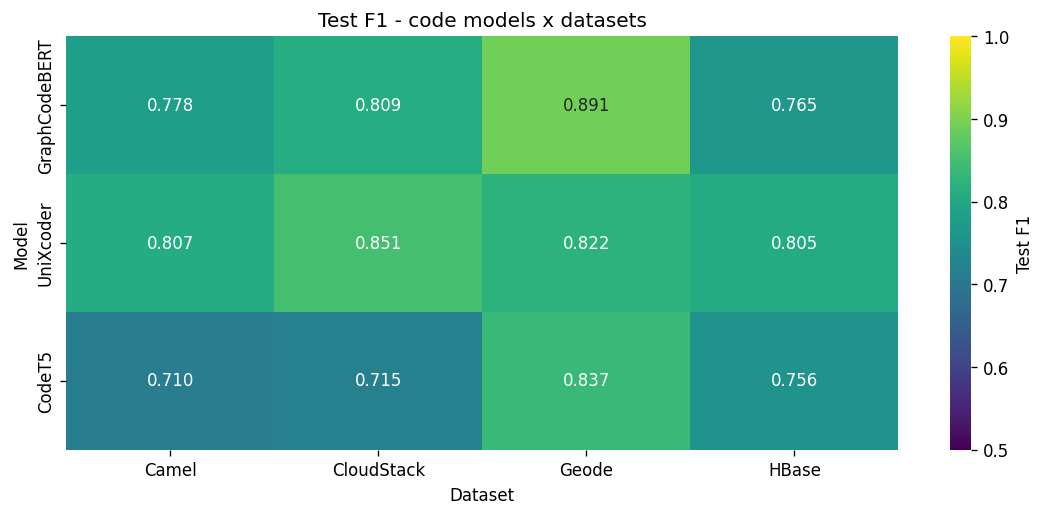

accuracy      f1  precision  recall
dataset    model                                             
Camel      GraphCodeBERT    0.7801  0.7779     0.7915  0.7801
           UniXcoder        0.8082  0.8073     0.8139  0.8082
           CodeT5           0.7118  0.7104     0.7163  0.7118
CloudStack GraphCodeBERT    0.8096  0.8088     0.8149  0.8096
           UniXcoder        0.8515  0.8514     0.8520  0.8515
           CodeT5           0.7176  0.7150     0.7256  0.7176
Geode      GraphCodeBERT    0.8908  0.8907     0.8932  0.8908
           UniXcoder        0.8222  0.8221     0.8231  0.8222
           CodeT5           0.8380  0.8371     0.8463  0.8380
HBase      GraphCodeBERT    0.7689  0.7655     0.7855  0.7689
           UniXcoder        0.8055  0.8055     0.8055  0.8055
           CodeT5           0.7583  0.7562     0.7678  0.7583

In [2]:
# Summary table + test-F1 heatmap (all three code models x datasets)
rows = [{"dataset": p, "model": m, **results_A[p][m]["metrics"]} for p in PRESENT for m in MODELS]
summary_A = pd.DataFrame(rows).set_index(["dataset", "model"])

f1_mat = pd.DataFrame({m: [results_A[p][m]["metrics"]["f1"] for p in PRESENT] for m in MODELS},
                      index=PRESENT).T
plt.figure(figsize=(1.6 * len(PRESENT) + 3, 0.8 * len(MODELS) + 2))
sns.heatmap(f1_mat, annot=True, fmt=".3f", cmap="viridis", vmin=0.5, vmax=1.0,
            cbar_kws={"label": "Test F1"})
plt.title("Test F1 - code models x datasets"); plt.ylabel("Model"); plt.xlabel("Dataset")
plt.tight_layout(); plt.show()
summary_A.round(4)

## A.3 — Grouped metric comparison (per dataset)

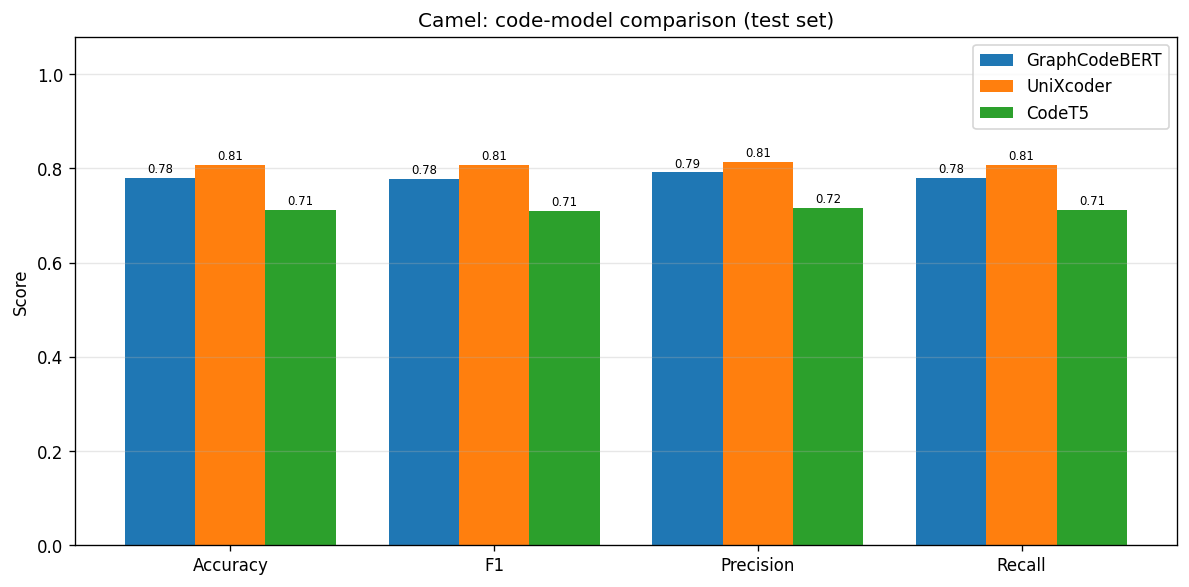

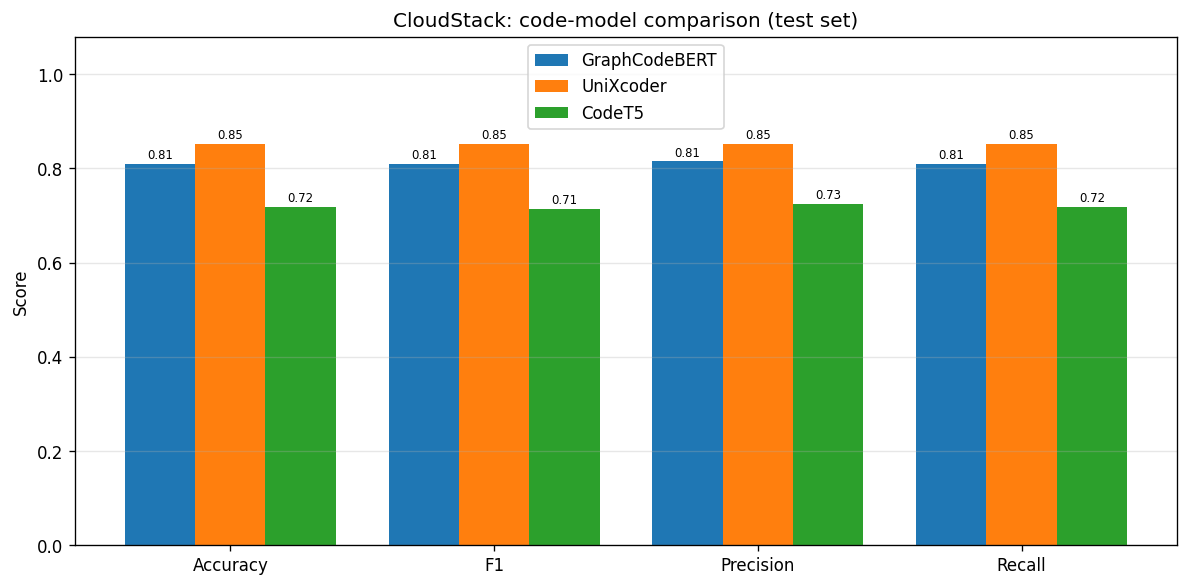

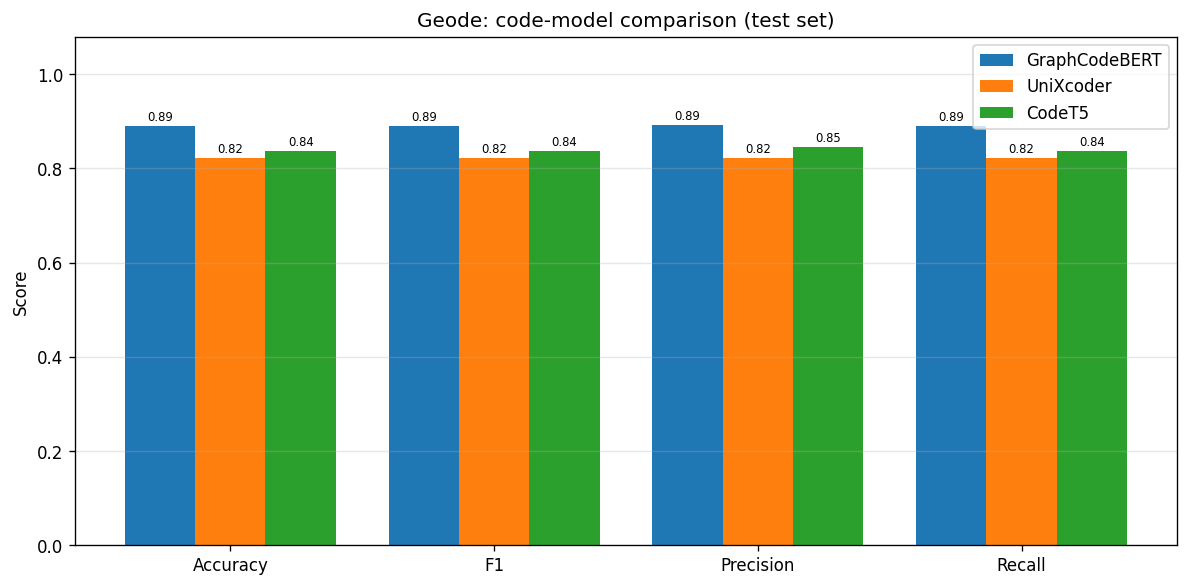

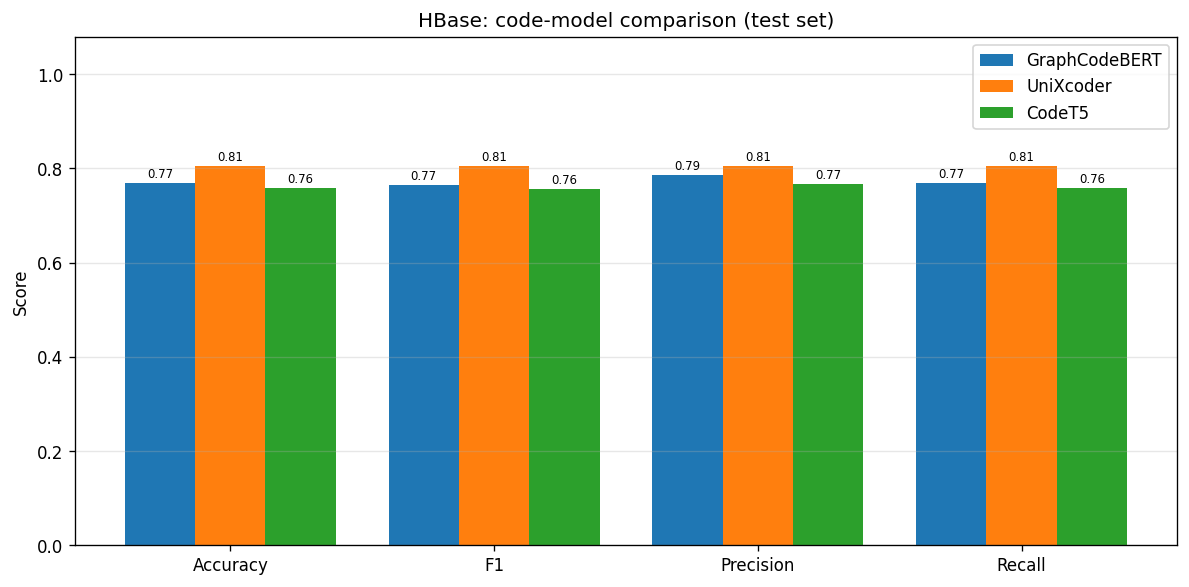

In [3]:
# Grouped metric comparison per dataset
metrics_order = ["accuracy", "f1", "precision", "recall"]; x = np.arange(len(metrics_order))
for proj in PRESENT:
    w = 0.8 / len(MODELS)
    plt.figure(figsize=(10, 5))
    for i, name in enumerate(MODELS):
        vals = [results_A[proj][name]["metrics"][mm] for mm in metrics_order]
        bars = plt.bar(x + (i - (len(MODELS) - 1) / 2) * w, vals, w, label=name)
        for b, v in zip(bars, vals):
            plt.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.2f}", ha="center", va="bottom", fontsize=7)
    plt.xticks(x, [m.capitalize() for m in metrics_order]); plt.ylim(0, 1.08)
    plt.ylabel("Score"); plt.title(f"{proj}: code-model comparison (test set)")
    plt.legend(); plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

## A.4 — Confusion matrices (per dataset)

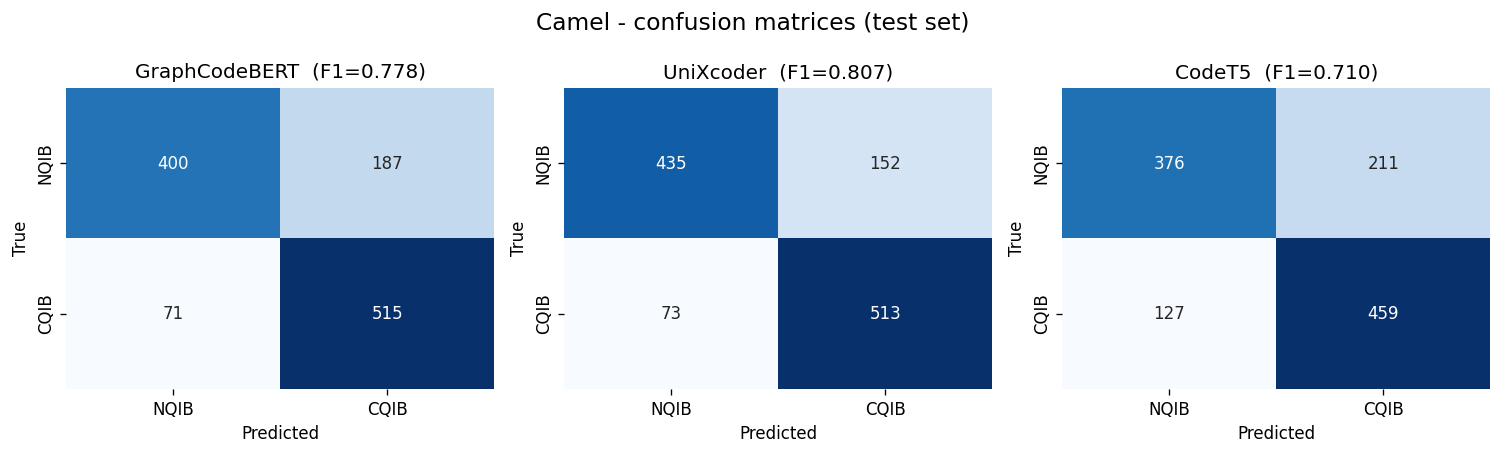

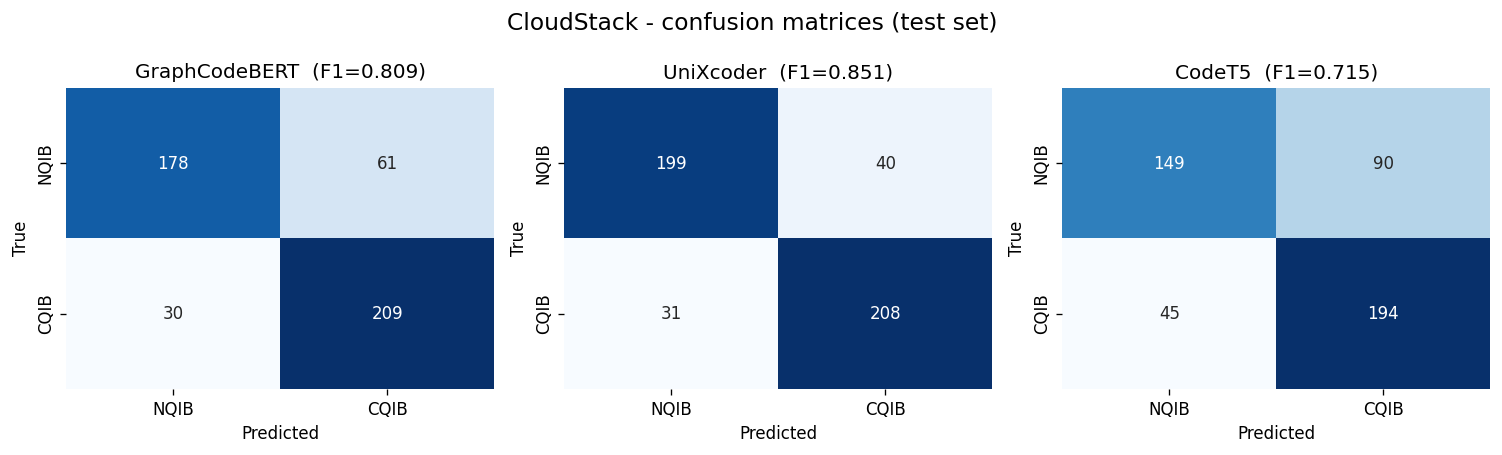

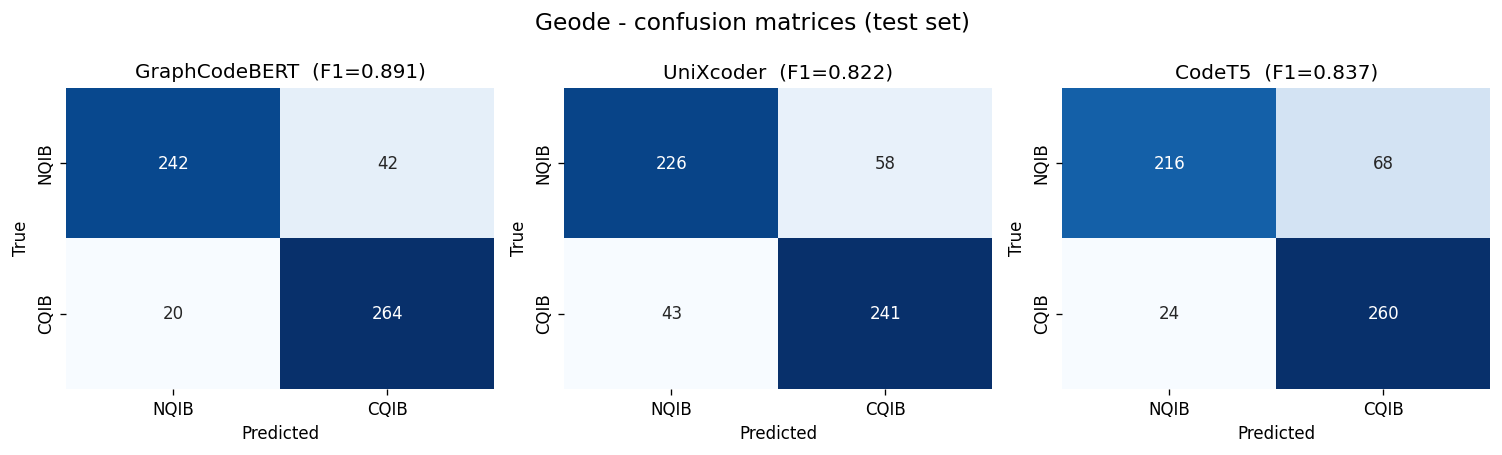

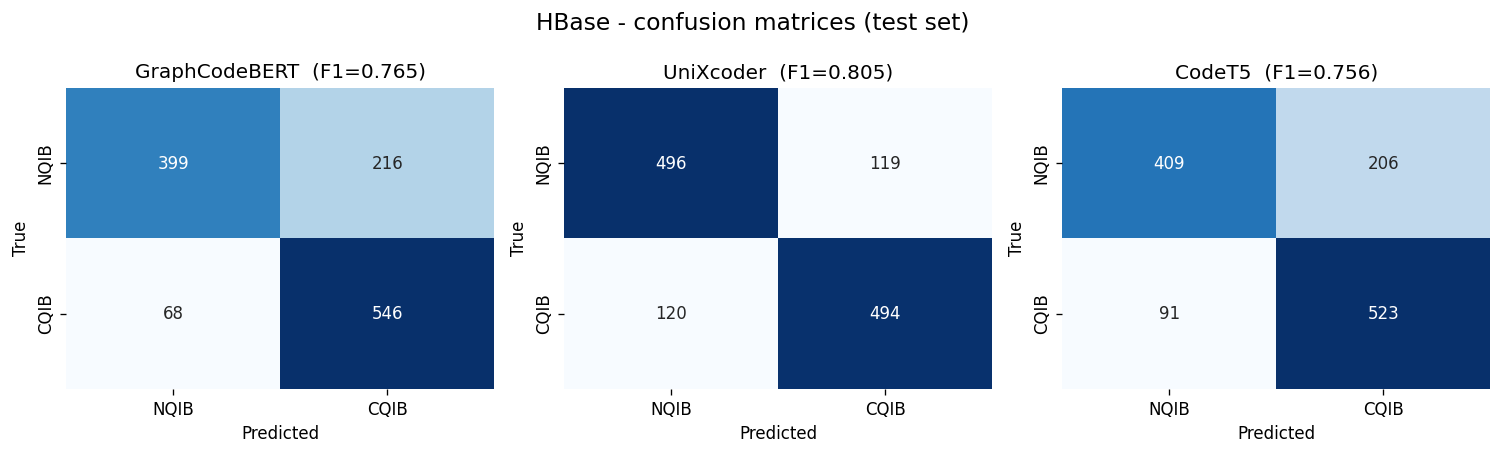

In [4]:
# Confusion matrices per dataset (GraphCodeBERT, UniXcoder, CodeT5)
for proj in PRESENT:
    n = len(MODELS); ncol = min(n, 3); nrow = math.ceil(n / ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.8 * nrow), squeeze=False)
    axes = axes.ravel()
    for ax, name in zip(axes, MODELS):
        res = results_A[proj][name]
        sns.heatmap(res["cm"], annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
        ax.set_title(f"{name}  (F1={res['metrics']['f1']:.3f})")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    for ax in axes[n:]:
        ax.axis("off")
    plt.suptitle(f"{proj} - confusion matrices (test set)", fontsize=14)
    plt.tight_layout(); plt.show()